## Import Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
csv_path = "/content/drive/MyDrive/Colab Notebooks/SignalsConsuegra.csv"
df = pd.read_csv(csv_path, sep=';', decimal=',', parse_dates=['Moment'])
df.rename(columns={'Moment': 'timestamp'}, inplace=True)
df = df.sort_values("timestamp").reset_index(drop=True)

## Feature Engineering Pipeline

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.6 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder
import re

def engineer_features(df_raw):
    """
    Takes a wide-format DataFrame `df_raw` with 'timestamp' and one column per station
    (as in station_cols), and returns:
      - df_features: long-format DataFrame ready for modelling
      - station_scalers: dict mapping station -> fitted RobustScaler
    """
    # 0) Copy & ensure timestamp column
    df = df_raw.copy()
    if df.index.name is not None or "timestamp" not in df.columns:
        df = df.reset_index().rename(columns={df.index.name or "index":"timestamp"})
    df = df.sort_values("timestamp").reset_index(drop=True) # ensure ascending order

    # 1) Rename value_<TAG> → <TAG>_VALUE
    station_cols = []
    rename_map = {}
    for col in df.columns:
        if re.search(r"_(value|VALUE|Value)$", col, re.IGNORECASE):
            new_col = re.sub(r"_(value|VALUE|Value)$", "", col, flags=re.IGNORECASE)
            rename_map[col] = new_col
            station_cols.append(new_col)

        elif re.search(r'^(value|VALUE|Value)_', col, re.IGNORECASE):
            new_col = re.sub(r'^(value|VALUE|Value)_', '', col, flags=re.IGNORECASE)
            rename_map[col] = new_col
            station_cols.append(new_col)

    df = df.rename(columns=rename_map)

    # 2) Melt into long form
    df = (
        df.melt(
            id_vars=["timestamp"],
            value_vars=station_cols,
            var_name="station",
            value_name="consumption"
        )
        .dropna(subset=["consumption"])
    )

    # 3) Convert timestamps to tz-aware UTC (no resampling needed under no-missing assumption)
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize('UTC') if df["timestamp"].dt.tz is None else df["timestamp"].dt.tz_convert('UTC')

    # 4) Leak detection + cleaning
    def clean_and_flag(g, z_threshold=4, roll_window=96):
        g = g.sort_values("timestamp")
        g["consumption_clamped"] = g["consumption"].clip(lower=0)

        rm = g["consumption_clamped"].rolling(roll_window, min_periods=1).mean()
        rs = g["consumption_clamped"].rolling(roll_window, min_periods=1).std()
        g["zscore_pos"]    = (g["consumption_clamped"] - rm) / (rs + 1e-9)
        g["is_leak_z_pos"] = (g["zscore_pos"] > z_threshold).astype(int)

        if len(g) > 100:
            iso = IsolationForest(contamination=0.01, random_state=42)
            g["is_leak_iso"] = (iso.fit_predict(g[["consumption_clamped"]]) == -1).astype(int)
        else:
            g["is_leak_iso"] = 0

        g["is_leak"] = ((g["is_leak_z_pos"]==1)|(g["is_leak_iso"]==1)).astype(int)
        gm = g["consumption_clamped"].rolling(24, min_periods=1).median()
        g["consumption_clean"] = np.where(g["is_leak"]==1, gm, g["consumption_clamped"])
        return g

    df = df.groupby("station", group_keys=False).apply(clean_and_flag).reset_index(drop=True)

    # Drop problematic station
    df = df[df.station != "GES450100021N00015"].reset_index(drop=True)

    return df

### Temporal Split and Station Scalers

In [ ]:
# temporal Split and station scalers
df_eng = engineer_features(df)

# Global sort by timestamp, split at 80%
df_eng = df_eng.sort_values("timestamp").reset_index(drop=True)
cutoff_idx = int(0.8 * len(df_eng))
cutoff_ts  = df_eng["timestamp"].iloc[cutoff_idx]
df_train   = df_eng[df_eng["timestamp"] < cutoff_ts].copy()
df_val     = df_eng[df_eng["timestamp"] >= cutoff_ts].copy()

station_scalers = {}
def scale_group_train(g):
    rs = RobustScaler()
    vals = g["consumption_clean"].values.reshape(-1,1)
    g["cons_scaled"] = rs.fit_transform(vals).flatten()
    station_scalers[g.name] = rs
    return g

df_train = df_train.groupby("station", group_keys=False).apply(scale_group_train).reset_index(drop=True)

def scale_group_val(g):
    if g.name in station_scalers:
        rs = station_scalers[g.name]
        vals = g["consumption_clean"].values.reshape(-1,1)
        g["cons_scaled"] = rs.transform(vals).flatten()
    else:
        g["cons_scaled"] = 0 # fallback for new stations
    return g

df_val = df_val.groupby("station", group_keys=False).apply(scale_group_val).reset_index(drop=True)

# Encoding: Fit on train, transform both
encoder = TargetEncoder(cols=["station"])
df_train["station_encoded"] = encoder.fit_transform(df_train["station"], df_train["cons_scaled"])
df_val["station_encoded"] = encoder.transform(df_val["station"])

/tmp/ipython-input-1556896462.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(clean_and_flag).reset_index(drop=True)
/tmp/ipython-input-423646746.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train = df_train.groupby("station", group_keys=False).apply(scale_group_train).reset_index(drop=True)
/tmp/ipython-input-423646746.py:30: DeprecationWar

### Add Features

In [ ]:
def add_features(g):
    g = g.sort_values("timestamp")
    t = g["cons_scaled"]
    for lag in [1,2,3,4,96,672]:
        g[f"lag_{lag}"] = t.shift(lag)
    g["diff_1"] = t - g["lag_1"]
    g["diff_96"] = t - g["lag_96"]
    for w,h in [(4,1),(24,6),(96,24)]:
        r = t.rolling(w, min_periods=1)
        g[f"mean_{h}h"] = r.mean()
        g[f"std_{h}h"] = r.std()
        g[f"med_{h}h"] = r.median()
        g[f"min_{h}h"] = r.min()
        g[f"max_{h}h"] = r.max()
    g["ewm_short"] = t.ewm(alpha=0.3, adjust=False).mean()
    ts = g["timestamp"]
    minutes = ts.dt.hour*60 + ts.dt.minute
    g["tod_sin"] = np.sin(2*np.pi*minutes/(24*60))
    g["tod_cos"] = np.cos(2*np.pi*minutes/(24*60))
    g["dow_sin"] = np.sin(2*np.pi*ts.dt.dayofweek/7)
    g["dow_cos"] = np.cos(2*np.pi*ts.dt.dayofweek/7)
    g["lag1_tod_interact"] = g["lag_1"] * g["tod_sin"]
    g["lag96_dow_interact"] = g["lag_96"] * g["dow_cos"]
    for i in range(1,4):
        g[f"sin_week_{i}"] = np.sin(2*np.pi*i*ts.dt.dayofyear/7)
        g[f"cos_week_{i}"] = np.cos(2*np.pi*i*ts.dt.dayofyear/7)
    return g.fillna(0)

df_train = df_train.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)
df_val = df_val.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)

/tmp/ipython-input-1046415392.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train = df_train.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)
/tmp/ipython-input-1046415392.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_val = df_val.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)


## Train Sliding Window XGBoost Model

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from datetime import time
import joblib
from joblib import  dump, load

# ─── 1) UTILITIES ──────────────────────────────────────────────────────────────

def compute_mase(y_true, y_pred, y_train, seasonality=96, eps=1e-8):
    mae = mean_absolute_error(y_true, y_pred)
    if len(y_train) < seasonality + 1:
        return np.nan
    naive = np.abs(y_train[seasonality:] - y_train[:-seasonality])
    mae_naive = np.mean(naive)
    if mae_naive < eps:
        return np.nan
    return mae / mae_naive

def get_indices_entire_sequence(length, window_size, step_size):
    idxs, s, e = [], 0, window_size
    while e <= length:
        idxs.append((s, e))
        s += step_size; e += step_size
    return idxs

def prepare_xy_pooled_with_time(df, features, target_col,
                                in_len, horizon, step_size):
    """
    Returns:
      X:    array (n_windows, in_len * n_feats)
      Y:    array (n_windows, horizon)
      H:    list of length n_windows, each an array of the in_len history
      T0:   DatetimeIndex of length n_windows, the timestamp of the first forecast step
    """
    Xs, Ys, Hs, T0s = [], [], [], []
    for st in df['station'].unique():
        sub = df[df['station']==st].sort_values('timestamp').reset_index(drop=True)
        feat_arr = sub[features + ['station_encoded']].to_numpy()
        targ_arr = sub[target_col].to_numpy()
        time_arr = sub['timestamp'].to_numpy()
        n = len(sub)
        win = in_len + horizon

        for (s,e) in get_indices_entire_sequence(n, win, step_size):
            xw = feat_arr[s:s+in_len]
            yw = targ_arr[s+in_len:s+in_len+horizon]
            if len(yw) < horizon:
                continue

            Xs.append(xw.flatten())
            Ys.append(yw)
            Hs.append(targ_arr[s:s+in_len])
            T0s.append(time_arr[s+in_len])

    X = np.vstack(Xs)
    Y = np.vstack(Ys)
    H = Hs
    T0 = pd.to_datetime(T0s)
    return X, Y, H, T0

# ─── 2) HYPERPARAMS & FEATURES ─────────────────────────────────────────────────

in_length = 96
horizon   = 96
step_size = 96

features = [
    "mean_1h","med_6h","std_6h",
    "lag_96","diff_96",
    "lag96_dow_interact","dow_sin","dow_cos",
    "is_leak_iso", "max_24h", "std_24h"
]

best_params = {
    'objective':        'reg:squarederror',
    'tree_method':      'hist',
    'device':           'cuda',
    'random_state':     42,
    'max_depth':        9,
    'learning_rate':    0.03823968436952936,
    'n_estimators':     366,
    'subsample':        0.801704069232722,
    'colsample_bytree': 0.789775025458991,
    'gamma':            0.000898038425726333,
    'reg_alpha':        2.7107447695850864,
    'reg_lambda':       2.0591320678176355
}

# ─── 3) BUILD WINDOWS ON TRAIN AND VAL SEPERATELY  ────────────────────────────────────────────────

X_tr, Y_tr, H_tr, T0_tr = prepare_xy_pooled_with_time(df_train, features, 'cons_scaled', in_length, horizon, step_size)
X_val, Y_val, H_val, T0_val = prepare_xy_pooled_with_time(df_val, features, 'cons_scaled', in_length, horizon, step_size)

# ─── 4) FIT MULTI‐OUTPUT XGBOOST ────────────────────────────────────────────────
"""
base = xgb.XGBRegressor(**best_params)
model = MultiOutputRegressor(base, n_jobs=4)
model.fit(X_tr, Y_tr)

# Save model, scalers, encoder
joblib.dump(model, "/content/drive/MyDrive/xgb_multioutput_model_v3.joblib")
joblib.dump(station_scalers,"/content/drive/MyDrive/xgb_station_scalers_v3.joblib")
joblib.dump(encoder, "/content/drive/MyDrive/xgb_encoder_v3.joblib")

# ─── 5) VALIDATION PLOTS ───────────────────

target_start_time = time(21, 0)
selected_indices = [i for i, ts in enumerate(T0_val) if ts.time() == target_start_time][:4]

plt.figure(figsize=(12, len(selected_indices)*3))
for j, i in enumerate(selected_indices):
    start_ts = T0_val[i]
    idx = pd.date_range(start=start_ts, periods=horizon, freq='15min', tz='UTC')
    actual = Y_val[i]
    forecast = model.predict(X_val[i].reshape(1, -1))[0]
    ax = plt.subplot(len(selected_indices), 1, j+1)
    ax.plot(idx, actual, marker='o', label='Actual')
    ax.plot(idx, forecast, marker='x', label='Forecast')
    ax.set_title(f"Validation Window {i+1} (starts {start_ts})")
    ax.set_ylabel("Scaled consumption")
    ax.legend()
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()"""

'\nbase = xgb.XGBRegressor(**best_params)\nmodel = MultiOutputRegressor(base, n_jobs=4)\nmodel.fit(X_tr, Y_tr)\n\n# Save model, scalers, encoder\njoblib.dump(model, "/content/drive/MyDrive/xgb_multioutput_model_v3.joblib")\njoblib.dump(station_scalers,"/content/drive/MyDrive/xgb_station_scalers_v3.joblib")\njoblib.dump(encoder, "/content/drive/MyDrive/xgb_encoder_v3.joblib")\n\n# ─── 5) VALIDATION PLOTS ───────────────────\n\ntarget_start_time = time(21, 0)\nselected_indices = [i for i, ts in enumerate(T0_val) if ts.time() == target_start_time][:4]\n\nplt.figure(figsize=(12, len(selected_indices)*3))\nfor j, i in enumerate(selected_indices):\n    start_ts = T0_val[i]\n    idx = pd.date_range(start=start_ts, periods=horizon, freq=\'15min\', tz=\'UTC\')\n    actual = Y_val[i]\n    forecast = model.predict(X_val[i].reshape(1, -1))[0]\n    ax = plt.subplot(len(selected_indices), 1, j+1)\n    ax.plot(idx, actual, marker=\'o\', label=\'Actual\')\n    ax.plot(idx, forecast, marker=\'x\', labe

In [ ]:
import joblib
from joblib import  dump, load
joblib.dump(model, "/content/drive/MyDrive/xgb_multioutput_model_v3.joblib")
joblib.dump(station_scalers,"/content/drive/MyDrive/xgb_station_scalers_v3.joblib")
joblib.dump(encoder, "/content/drive/MyDrive/xgb_encoder_v3.joblib")

# ─── 5) VALIDATION PLOTS ───────────────────

target_start_time = time(21, 0)
selected_indices = [i for i, ts in enumerate(T0_val) if ts.time() == target_start_time][:4]

# Fallback if no 21:00 starts (common due to data alignment and 24h steps)
if not selected_indices:
    print("Warning: No validation windows starting at 21:00. Plotting the first 4 windows instead.")
    selected_indices = list(range(min(4, len(T0_val))))

# Skip if still no windows (e.g., val too small)
if not selected_indices:
    print("No validation windows available to plot. Check if df_val has enough data (>= in_length + horizon per station).")
else:
    plt.figure(figsize=(12, len(selected_indices)*3))
    for j, i in enumerate(selected_indices):
        start_ts = T0_val[i]
        idx = pd.date_range(start=start_ts, periods=horizon, freq='15min', tz='UTC')  # Explicit TZ to match data
        actual = Y_val[i]
        forecast = model.predict(X_val[i].reshape(1, -1))[0]
        ax = plt.subplot(len(selected_indices), 1, j+1)
        ax.plot(idx, actual, marker='o', label='Actual')
        ax.plot(idx, forecast, marker='x', label='Forecast')
        ax.set_title(f"Validation Window {i+1} (starts {start_ts})")
        ax.set_ylabel("Scaled consumption")
        ax.legend()
    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

# Optional: Compute overall MASE on val to confirm model (uses your histories H_val as y_train proxy)
if len(Y_val) > 0:
    all_preds = model.predict(X_val)
    mase_scores = []
    for idx in range(len(Y_val)):
        y_true = Y_val[idx]
        y_pred = all_preds[idx]
        y_hist = H_val[idx]  # History as naive baseline proxy
        mase = compute_mase(y_true, y_pred, y_hist)
        if not np.isnan(mase):
            mase_scores.append(mase)
    if mase_scores:
        print(f"Average MASE on validation: {np.mean(mase_scores):.4f} (lower is better, <1 beats naive seasonal)")
    else:
        print("No valid MASE scores (check data length/seasonality).")
else:
    print("No validation data—ensure df_val is not empty after split.")

NameError: name 'model' is not defined

In [ ]:
# Save Model
from joblib import dump
dump(model, "insert drive path")

In [ ]:
import joblib
# Load Model
from joblib import load
model = load("/content/drive/MyDrive/xgb_multioutput_model_v3.joblib")

## Fetch Real-Time data from API

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import pytz
from getpass import getpass

# ——— 1) CONFIG ———
OAUTH_URL    = "https://authentication.gestagua.es/auth/realms/Gestagua/protocol/openid-connect/token"
API_BASE     = "https://hermesmanager.saur.com.es/api"
CLIENT_ID    = "hermes-app"
USERNAME     = "juan.fernandez@saur.com"
PASSWORD     = getpass("Password: ")
TIMEZONE     = "Europe/Madrid"

def get_token():
  payload = {
    'client_id': CLIENT_ID,
    'username': USERNAME,
    'password': PASSWORD,
    'grant_type': 'password'
  }

  resp = requests.post(OAUTH_URL, data=payload)
  resp.raise_for_status()
  return resp.json()['access_token']

token = get_token()
headers = {
    'Authorization': f'Bearer {token}',
    "Content-Type": "application/json"
    }

station_tags =  ["GES450100045N00016","GES450100045N00015","GES450100045N00006", 'GES450170010N00008', 'GES450100039N00015',
        'GES450100021N00015', 'GES450100024N00015', 'GES450100020N00012', 'GES450100020N00013',
        'GES450100010N00015']

# ——— 3) BUILD YOUR DATE RANGE ———
tz = pytz.timezone(TIMEZONE)
end_dt   = datetime.now(tz)
start_dt = end_dt - timedelta(days=60)

# format in ISO UTC (with trailing Z)
start_str = start_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
end_str   =   end_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

# ——— BATCH REQUEST FOR MULTIPLE SIGNALS ———
def fetch_historic_batch(tags, start, end, top=10000):
    url  = f"{API_BASE}/Historic/listHistoric"
    bodies = []
    for tag in tags:
        bodies.append({
          "startDate":  start,
          "endDate":    end,
          "tzi":        TIMEZONE,
          "interval":   0,
          "top":        top,
          "skip":       0,
          "prev":       False,
          "next":       False,
          "dataVersion":"RAW",
          "asc":        True,
          "tag":         tag
        })
    r = requests.post(url, json=bodies, headers=headers)
    r.raise_for_status()
    return r.json()

batch = fetch_historic_batch(station_tags, start_str, end_str)

# parse each into a single DF with a column per signal
dfs = []

for hist in batch.get("historics", []):
    entry = hist.get("data", {})
    sig_id = entry.get("id")
    tag    = entry.get("tag")
    #→ The human‐readable tag name (optional)

    block  = entry.get("data", {})
    #→ The sub‐block with actual time/value arrays

    ms_list = block.get("ms") or []
    #→ Millisecond timestamps array, or empty if missing

    vs_dict = block.get("vs") or {}
    #→ Dict mapping string keys (“0”, “1”, …) to value arrays

    # Extract the first (and usually only) array in vs_dict
    if isinstance(vs_dict, dict) and vs_dict:
        first_key = next(iter(vs_dict))
        values    = vs_dict.get(first_key) or []
    else:
        values    = []

    if ms_list and isinstance(ms_list[0], str):
        timestamps = pd.to_datetime(ms_list)
    else:
        timestamps = pd.to_datetime(ms_list, unit="ms")

    if len(timestamps) == len(values):
        df_tmp = pd.DataFrame({f"value_{tag}": values}, index=timestamps)
        dfs.append(df_tmp)
    else:
        print(f"⚠️ Length mismatch for {tag}: {len(timestamps)} vs {len(values)}")

# Combine them side‐by‐side on the timestamp index
if dfs:
    df_api = pd.concat(dfs, axis=1).sort_index()
else:
    df_api = pd.DataFrame()

df_api = df_api.reset_index()
df_api = df_api.rename(columns={'index': 'timestamp'})
df_api['timestamp'] = pd.to_datetime(df_api['timestamp'])
df_api = df_api.sort_values("timestamp").set_index('timestamp')

print("Combined DataFrame of all signals:")
print(df_api.head())

Password: ··········
Combined DataFrame of all signals:
                           value_GES450100045N00016  value_GES450100045N00015  \
timestamp                                                                       
2025-06-07 09:00:00+00:00                     4.896                 19.600000   
2025-06-07 09:15:00+00:00                     4.988                 21.480000   
2025-06-07 09:30:00+00:00                     5.172                 21.920000   
2025-06-07 09:45:00+00:00                     4.360                 23.879999   
2025-06-07 10:00:00+00:00                     4.292                 22.240000   

                           value_GES450100045N00006  value_GES450170010N00008  \
timestamp                                                                       
2025-06-07 09:00:00+00:00                  3.142443                 32.304002   
2025-06-07 09:15:00+00:00                  3.129778                 37.572002   
2025-06-07 09:30:00+00:00                  3.104295 

## Plot Forecast

In [ ]:
import joblib
# Inference Pipeline
# Load saved artifacts from training

#model = joblib.load("/content/drive/MyDrive/xgb_multioutput_model_v3.joblib")
#station_scalers = joblib.load("/content/drive/MyDrive/xgb_station_scalers_v3.joblib")
#encoder = joblib.load("/content/drive/MyDrive/xgb_encoder_v3.joblib")

# Constants from training
features = [
    "mean_1h", "med_6h", "std_6h",
    "lag_96", "diff_96",
    "lag96_dow_interact", "dow_sin", "dow_cos",
    "is_leak_iso", "max_24h", "std_24h"
]
horizon = 96  # 24 hours at 15-min
IN_LENGTH = 96
FREQ = "15min"

# Production engineering function (transform only)
def engineer_features_prod(df_raw, station_scalers, encoder):
    df = df_raw.reset_index().copy()  # Reset index to make timestamp a column
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Robust rename
    station_cols = []
    rename_map = {}
    for col in df.columns:
        if re.search(r'_(value|VALUE|Value)$', col, re.IGNORECASE):
            new_col = re.sub(r'_(value|VALUE|Value)$', '', col, flags=re.IGNORECASE)
            rename_map[col] = new_col
            station_cols.append(new_col)
        elif re.search(r'^(value|VALUE|Value)_', col, re.IGNORECASE):
            new_col = re.sub(r'^(value|VALUE|Value)_', '', col, flags=re.IGNORECASE)
            rename_map[col] = new_col
            station_cols.append(new_col)
    df = df.rename(columns=rename_map)

    # Melt
    df = df.melt(id_vars=["timestamp"], value_vars=station_cols, var_name="station", value_name="consumption").dropna(subset=["consumption"])

    # TZ-aware
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize('UTC') if df["timestamp"].dt.tz is None else df["timestamp"].dt.tz_convert('UTC')

    # Clean and flag
    def clean_and_flag(g, z_threshold=4, roll_window=96):
        g = g.sort_values("timestamp")
        g["consumption_clamped"] = g["consumption"].clip(lower=0)
        rm = g["consumption_clamped"].rolling(roll_window, min_periods=1).mean()
        rs = g["consumption_clamped"].rolling(roll_window, min_periods=1).std()
        g["zscore_pos"] = (g["consumption_clamped"] - rm) / (rs + 1e-9)
        g["is_leak_z_pos"] = (g["zscore_pos"] > z_threshold).astype(int)
        if len(g) > 100:
            iso = IsolationForest(contamination=0.01, random_state=42)
            g["is_leak_iso"] = (iso.fit_predict(g[["consumption_clamped"]]) == -1).astype(int)
        else:
            g["is_leak_iso"] = 0
        g["is_leak"] = ((g["is_leak_z_pos"]==1)|(g["is_leak_iso"]==1)).astype(int)
        gm = g["consumption_clamped"].rolling(24, min_periods=1).median()
        g["consumption_clean"] = np.where(g["is_leak"]==1, gm, g["consumption_clamped"])
        return g

    df = df.groupby("station", group_keys=False).apply(clean_and_flag).reset_index(drop=True)

    # Scale: Transform with loaded scalers
    def scale_group_prod(g):
        if g.name in station_scalers:
            rs = station_scalers[g.name]
            vals = g["consumption_clean"].values.reshape(-1,1)
            g["cons_scaled"] = rs.transform(vals).flatten()
        else:
            # Fallback for new station
            from sklearn.preprocessing import RobustScaler
            rs = RobustScaler()
            g["cons_scaled"] = rs.fit_transform(g["consumption_clean"].values.reshape(-1,1)).flatten()
            print(f"Warning: New station {g.name} - using on-the-fly scaler")
        return g
    df = df.groupby("station", group_keys=False).apply(scale_group_prod).reset_index(drop=True)

    # Encode: Transform with loaded encoder
    df["station_encoded"] = encoder.transform(df["station"])

    # Add features
    def add_features(g):
        g = g.sort_values("timestamp")
        t = g["cons_scaled"]
        for lag in [1,2,3,4,96,672]:
            g[f"lag_{lag}"] = t.shift(lag)
        g["diff_1"] = t - g["lag_1"]
        g["diff_96"] = t - g["lag_96"]
        for w,h in [(4,1),(24,6),(96,24)]:
            r = t.rolling(w, min_periods=1)
            g[f"mean_{h}h"] = r.mean()
            g[f"std_{h}h"] = r.std()
            g[f"med_{h}h"] = r.median()
            g[f"min_{h}h"] = r.min()
            g[f"max_{h}h"] = r.max()
        g["ewm_short"] = t.ewm(alpha=0.3, adjust=False).mean()
        ts = g["timestamp"]
        minutes = ts.dt.hour*60 + ts.dt.minute
        g["tod_sin"] = np.sin(2*np.pi*minutes/(24*60))
        g["tod_cos"] = np.cos(2*np.pi*minutes/(24*60))
        g["dow_sin"] = np.sin(2*np.pi*ts.dt.dayofweek/7)
        g["dow_cos"] = np.cos(2*np.pi*ts.dt.dayofweek/7)
        g["lag1_tod_interact"] = g["lag_1"] * g["tod_sin"]
        g["lag96_dow_interact"] = g["lag_96"] * g["dow_cos"]
        for i in range(1,4):
            g[f"sin_week_{i}"] = np.sin(2*np.pi*i*ts.dt.dayofyear/7)
            g[f"cos_week_{i}"] = np.cos(2*np.pi*i*ts.dt.dayofyear/7)
        return g.fillna(0)

    df = df.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)

    # Drop problematic station
    df = df[df.station != "GES450100021N00015"].reset_index(drop=True)

    return df

# Process API data
df_prod = engineer_features_prod(df_api, station_scalers, encoder)

def make_forecast(station, df_prod, model, station_scalers, features, in_len, horizon, freq):
    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, computed_last_ts = build_last_window(df_prod, station, features, in_len)

    first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
    print(f"Forecast starts at: {first_fc_ts}")

    y_scaled = model.predict(X_in)[0]
    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")
    y_raw = scaler.inverse_transform(y_scaled.reshape(-1,1)).flatten()

    future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=freq, tz='UTC')
    forecast = pd.Series(y_raw, index=future_idx, name="Forecast")

    # Optional: Past actuals for plotting
    df_station = df_prod[df_prod["station"] == station].set_index("timestamp").sort_index()
    last_obs_ts = computed_last_ts
    past_start = last_obs_ts - pd.Timedelta(days=2)
    past_idx = pd.date_range(start=past_start, end=last_obs_ts, freq=freq, tz='UTC')
    actual = df_station["consumption_clean"].reindex(past_idx).interpolate(method='time')

    return forecast, actual, last_obs_ts

"""
Imported stations =  ["GES450100045N00016","GES450100045N00015","GES450100045N00006", 'GES450170010N00008', 'GES450100039N00015',
        'GES450100021N00015', 'GES450100024N00015', 'GES450100020N00012', 'GES450100020N00013',
        'GES450100010N00015']

# Example usage: Forecast for one station and plot
station = "GES450100020N00012"  # Change as needed
forecast, actual, last_obs_ts = make_forecast(station, df_prod, model, station_scalers, features, IN_LENGTH, horizon, FREQ)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual, label="Actual (last 2 days)")
ax.plot(forecast, "--", label="Forecast (24 h)")
ax.axvline(last_obs_ts, linestyle="--", alpha=0.7, label="Forecast start")
ax.set_title(f"{station}: Actual → 24 h Forecast")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption (m³ per 15 min)")
ax.legend()
plt.tight_layout()
plt.show()

# To forecast for all stations:
forecasts = {}
for st in df_prod['station'].unique():
    try:
        forecast, _, _ = make_forecast(st, df_prod, model, station_scalers, features, IN_LENGTH, horizon, FREQ)
        forecasts[st] = forecast
    except ValueError as e:
        print(f"Skipping {st}: {e}")

print("Forecasts:", forecasts)

"""

/tmp/ipython-input-3325631816.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(clean_and_flag).reset_index(drop=True)
/tmp/ipython-input-3325631816.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(scale_group_prod).reset_index(drop=True)


/tmp/ipython-input-3325631816.py:112: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)


'\nImported stations =  ["GES450100045N00016","GES450100045N00015","GES450100045N00006", \'GES450170010N00008\', \'GES450100039N00015\',\n        \'GES450100021N00015\', \'GES450100024N00015\', \'GES450100020N00012\', \'GES450100020N00013\',\n        \'GES450100010N00015\']\n\n# Example usage: Forecast for one station and plot\nstation = "GES450100020N00012"  # Change as needed\nforecast, actual, last_obs_ts = make_forecast(station, df_prod, model, station_scalers, features, IN_LENGTH, horizon, FREQ)\n\nfig, ax = plt.subplots(figsize=(12, 5))\nax.plot(actual, label="Actual (last 2 days)")\nax.plot(forecast, "--", label="Forecast (24 h)")\nax.axvline(last_obs_ts, linestyle="--", alpha=0.7, label="Forecast start")\nax.set_title(f"{station}: Actual → 24 h Forecast")\nax.set_xlabel("Timestamp")\nax.set_ylabel("Consumption (m³ per 15 min)")\nax.legend()\nplt.tight_layout()\nplt.show()\n\n# To forecast for all stations:\nforecasts = {}\nfor st in df_prod[\'station\'].unique():\n    try:\n   

### Compare Forecasts

In [ ]:
from sklearn.metrics import mean_absolute_error

def process_batch_to_df(batch):
    dfs = []
    for hist in batch.get("historics", []):
        entry = hist.get("data", {})
        tag = entry.get("tag")
        block = entry.get("data", {})
        ms_list = block.get("ms") or []
        vs_dict = block.get("vs") or {}
        if isinstance(vs_dict, dict) and vs_dict:
            first_key = next(iter(vs_dict))
            values = vs_dict.get(first_key) or []
        else:
            values = []
        if ms_list and isinstance(ms_list[0], str):
            timestamps = pd.to_datetime(ms_list)
        else:
            timestamps = pd.to_datetime(ms_list, unit="ms")
        if len(timestamps) == len(values):
            df_tmp = pd.DataFrame({f"value_{tag}": values}, index=timestamps)
            dfs.append(df_tmp)
        else:
            print(f"⚠️ Length mismatch for {tag}: {len(timestamps)} vs {len(values)}")
    if dfs:
        df_api = pd.concat(dfs, axis=1).sort_index()
    else:
        df_api = pd.DataFrame()
    df_api = df_api.reset_index().rename(columns={'index': 'timestamp'})
    df_api['timestamp'] = pd.to_datetime(df_api['timestamp'])
    df_api = df_api.sort_values("timestamp").set_index('timestamp')
    return df_api

# —— STEP 1: FETCH DATA UP TO JULY 22 TO REGENERATE FORECAST FOR JULY 23 ——
tz = pytz.timezone(TIMEZONE)
july22_end = datetime(2025, 7, 26, 23, 59, 59, tzinfo=tz)  # End of July 22
july22_start = july22_end - timedelta(days=60)

july22_start_str = july22_start.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
july22_end_str = july22_end.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

batch_july22 = fetch_historic_batch(station_tags, july22_start_str, july22_end_str)
df_api_july22 = process_batch_to_df(batch_july22)
df_prod_july22 = engineer_features_prod(df_api_july22, station_scalers, encoder)

# Regenerate forecast for July 23
station = "GES450100020N00012"
def make_forecast(station, df_prod, model, station_scalers, features, in_len, horizon, freq):
    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, computed_last_ts = build_last_window(df_prod, station, features, in_len)

    first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
    print(f"Regenerated forecast for July 23 starts at: {first_fc_ts}")

    y_scaled = model.predict(X_in)[0]
    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")
    y_raw = scaler.inverse_transform(y_scaled.reshape(-1,1)).flatten()

    future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=freq, tz='UTC')
    forecast = pd.Series(y_raw, index=future_idx, name="Forecast")

    return forecast, computed_last_ts

july23_forecast, last_obs_ts = make_forecast(station, df_prod_july22, model, station_scalers, features, IN_LENGTH, horizon, FREQ)

# —— STEP 2: FETCH FULL DATA UP TO NOW FOR JULY 23 ACTUALS ——
end_dt = datetime.now(tz)
start_dt = end_dt - timedelta(days=60)

start_str = start_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
end_str = end_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

batch_full = fetch_historic_batch(station_tags, start_str, end_str)
df_api_full = process_batch_to_df(batch_full)
df_prod_full = engineer_features_prod(df_api_full, station_scalers, encoder)

# Extract actuals for July 23
df_station_full = df_prod_full[df_prod_full["station"] == station].set_index("timestamp").sort_index()
fc_start = july23_forecast.index[0]
fc_end = july23_forecast.index[-1]
fc_idx = pd.date_range(start=fc_start, end=fc_end, freq=FREQ, tz='UTC')
actual_july23 = df_station_full["consumption_clean"].reindex(fc_idx).interpolate(method='time')

if actual_july23.isna().any():
    print("Warning: Some actuals missing - filling.")
    actual_july23 = actual_july23.ffill().bfill()

# —— STEP 3: METRICS AND PLOT WITH LAST 2 DAYS ——
if len(actual_july23) == len(july23_forecast):
    mae = mean_absolute_error(actual_july23, july23_forecast)
    history = df_station_full["consumption_clean"].loc[:fc_start - pd.Timedelta(minutes=15)].tail(96).values
    if len(history) >= 96:
        naive_errors = np.abs(history[96:] - history[:-96])
        mae_naive = np.mean(naive_errors) if len(naive_errors) > 0 else 1e-8
        mase = mae / mae_naive
        print(f"MAE: {mae:.4f}, MASE: {mase:.4f}")
    else:
        print(f"MAE: {mae:.4f} (no MASE)")
else:
    overlap_len = min(len(actual_july23), len(july23_forecast))
    mae = mean_absolute_error(actual_july23.iloc[:overlap_len], july23_forecast.iloc[:overlap_len])
    print(f"Partial MAE: {mae:.4f}")

# Extended actuals for last 2 days + forecast period
extended_start = fc_start - pd.Timedelta(days=1)
extended_idx = pd.date_range(start=extended_start, end=fc_end, freq=FREQ, tz='UTC')
extended_actual = df_station_full["consumption_clean"].reindex(extended_idx).interpolate(method='time')
if extended_actual.isna().any():
    extended_actual = extended_actual.ffill().bfill()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(extended_actual, label="Actual (last 2 days + July 27)")
ax.plot(july23_forecast, "--", label="July 27 Forecast")
ax.axvline(fc_start, linestyle="--", alpha=0.7, label="Forecast start")
#ax.set_title(f"{station}: July 25 Forecast vs. Actual (with last 2 days)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption (m³ per 15 min)")
ax.legend()
plt.tight_layout()
plt.show()

### Last 7 days Forecast

In [ ]:
# Fetch data from last 7 days + BUFFER

tz = pytz.timezone(TIMEZONE)
end_dt = datetime.now(tz)
start_dt = end_dt - timedelta(days=67)

start_str = start_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
end_str = end_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

batch_full = fetch_historic_batch(station_tags, start_str, end_str)
df_api_full = process_batch_to_df(batch_full)
df_prod_full = engineer_features_prod(df_api_full, station_scalers, encoder)

# —— SIMULATE DAILY FORECASTS FOR LAST 7 DAYS ——
station = "GES450100020N00012"  # Change as needed
forecasts = {}
maes = {}

# Last 7 days end dates (e.g., for July 24 current, simulate forecasts as if run on July 17 for July 18, etc.)
current_date = datetime(2025, 7, 24, tzinfo=tz)  # Fixed as per current date
for day_offset in range(2, 0, -1):  # From 7 days ago to yesterday
    forecast_day = current_date - timedelta(days=day_offset - 1)  # e.g., for offset=7, forecast_day=July 18
    prev_day_end = forecast_day - timedelta(days=1)  # End of day before forecast (input data up to here)

    # Filter df_prod_full to data up to prev_day_end (simulate historical fetch)
    df_prod_hist = df_prod_full[df_prod_full['timestamp'] <= prev_day_end]

    # Generate forecast
    try:
        def build_last_window(df, station_tag, feats, in_len):
            sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
            if len(sub) < in_len:
                raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
            block = sub.iloc[-in_len:]
            Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
            return Xw, block["timestamp"].iloc[-1]

        X_in, computed_last_ts = build_last_window(df_prod_hist, station, features, IN_LENGTH)

        first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
        print(f"Simulated forecast for {forecast_day.date()} starts at: {first_fc_ts}")

        y_scaled = model.predict(X_in)[0]
        scaler = station_scalers.get(station)
        if scaler is None:
            raise ValueError(f"No scaler for station {station}")
        y_raw = scaler.inverse_transform(y_scaled.reshape(-1,1)).flatten()

        future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=FREQ, tz='UTC')
        forecast = pd.Series(y_raw, index=future_idx, name="Forecast")

        forecasts[forecast_day.date()] = forecast

        # Extract actual for this day from full data
        fc_end = first_fc_ts + pd.Timedelta(hours=24) - pd.Timedelta(minutes=15)
        fc_idx = pd.date_range(start=first_fc_ts, end=fc_end, freq=FREQ, tz='UTC')
        actual_day = df_prod_full[df_prod_full['station'] == station].set_index('timestamp')['consumption_clean'].reindex(fc_idx).interpolate(method='time')
        if actual_day.isna().any():
            actual_day = actual_day.ffill().bfill()

        # MAE for this day
        mae = mean_absolute_error(actual_day, forecast)
        maes[forecast_day.date()] = mae
        print(f"MAE for {forecast_day.date()}: {mae:.4f}")
    except ValueError as e:
        print(f"Skipping forecast for {forecast_day.date()}: {e}")

# —— PLOT ALL FORECASTS ON TOP OF ACTUALS ——
df_station_full = df_prod_full[df_prod_full["station"] == station].set_index("timestamp").sort_index()
week_start = current_date - timedelta(days=4)
week_end = current_date
week_idx = pd.date_range(start=week_start, end=week_end, freq=FREQ)
actual_week = df_station_full["consumption_clean"].reindex(week_idx).interpolate(method='time')
if actual_week.isna().any():
    actual_week = actual_week.ffill().bfill()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(actual_week, label="Actual (last 7 days)", linewidth=2)

# Plot each day's forecast as dashed line
colors = plt.cm.viridis(np.linspace(0, 1, len(forecasts)))  # Color per day
for i, (day, forecast) in enumerate(forecasts.items()):
    ax.plot(forecast, "--", label=f"Forecast for {day}", color=colors[i])

ax.set_title(f"{station}: Simulated Daily Forecasts vs. Actuals (Last 7 Days)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption (m³ per 15 min)")
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

# Print MAEs
print("\nMAEs for each day:")
for day, mae in maes.items():
    print(f"{day}: {mae:.4f}")

# Train High Variance Model

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
params_v4 = {
    'objective':        'reg:squarederror',
    'tree_method':      'hist',
    'device':           'cuda',
    'random_state':     42,
    'max_depth':        9,
    'learning_rate':    0.02823968436952936,
    'n_estimators':     450,
    'subsample':        0.801704069232722,
    'colsample_bytree': 0.789775025458991,
    'gamma':            0.000898038425726333,
    'reg_alpha':        0.4107447695850864,
    'reg_lambda':       0.3591320678176355
}

base = xgb.XGBRegressor(**params_v4)
model4 = MultiOutputRegressor(base, n_jobs=4)
model4.fit(X_tr, Y_tr)

In [ ]:
import joblib

joblib.dump(model4,"/content/drive/MyDrive/xgb_multioutput_model_v4_high_variance.joblib" )

# Train Quantile Regression Sliding Window Model

In [ ]:

# Train Quantile Models

# Lower (0.05)
params_lower = {**best_params, 'objective': 'reg:quantileerror', 'quantile_alpha': 0.05}
base_lower = xgb.XGBRegressor(**params_lower)
model_lower = MultiOutputRegressor(base_lower, n_jobs=4)
model_lower.fit(X_tr, Y_tr)

# Median (0.5, robust mean-like)
params_median = {**best_params, 'objective': 'reg:quantileerror', 'quantile_alpha': 0.5}
base_median = xgb.XGBRegressor(**params_median)
model_median = MultiOutputRegressor(base_median, n_jobs=4)
model_median.fit(X_tr, Y_tr)

# Upper (0.95)
params_upper = {**best_params, 'objective': 'reg:quantileerror', 'quantile_alpha': 0.95}
base_upper = xgb.XGBRegressor(**params_upper)
model_upper = MultiOutputRegressor(base_upper, n_jobs=4)
model_upper.fit(X_tr, Y_tr)

# Save
joblib.dump(model_lower, '/content/drive/MyDrive/quantile_lower_model_v2.joblib')
joblib.dump(model_median, '/content/drive/MyDrive/quantile_median_model_v2.joblib')
joblib.dump(model_upper, '/content/drive/MyDrive/quantile_upper_model_v2.joblib')
joblib.dump(station_scalers, '/content/drive/MyDrive/station_scalers.joblib')
joblib.dump(encoder, '/content/drive/MyDrive/target_encoder.joblib')

print("Trained and saved quantile models.")

In [3]:
!pip install mapie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 kB 3.0 MB/s eta 0:00:00


In [5]:
import mapie
print(mapie.__version__)

1.0.1


In [ ]:
# Load quantile models
model_lower = joblib.load('/content/drive/MyDrive/quantile_lower_model_v2.joblib')
model_median = joblib.load('/content/drive/MyDrive/quantile_median_model_v2.joblib')
model_upper = joblib.load('/content/drive/MyDrive/quantile_upper_model_v2.joblib')
station_scalers = joblib.load('/content/drive/MyDrive/station_scalers.joblib')
encoder = joblib.load('/content/drive/MyDrive/target_encoder.joblib')
#strat_res_median = joblib.load('/content/drive/MyDrive/strat_residuals.joblib')
#vol_thresh = joblib.load('/content/drive/MyDrive/vol_thresh.joblib')

In [ ]:
import os
import xgboost as xgb

os.makedirs('/content/drive/MyDrive/exported_estimators', exist_ok=True)

# Extract and save each estimator as JSON
for h in range(96):  # Your horizon=96
    estimator = model_median.estimators_[h]
    filepath = f'/content/drive/MyDrive/exported_estimators/estimator_h{h}.json'
    estimator.save_model(filepath)  # Saves as JSON (default in recent XGBoost)
    print(f"Saved horizon {h} to {filepath}")

In [ ]:
import mapie.regression
print(mapie.__version__)

In [ ]:
# Confirm GPU setup

import xgboost as xgb
import torch
print("XGBoost version:", xgb.__version__)  # Should be >=2.0
print("CUDA available:", torch.cuda.is_available())  # True if GPU ready
print("Device in params:", 'cuda' in str(model_median.get_params()))
!nvidia-smi  # Check GPU memory/usage

## Compute Artifacts for Ensemble Batch Prediction Interval

In [ ]:
# Compute artfifacts fro bootstrap and conformal on validation set (gpu)

# Predict raw quantiles on val
Y_lower_val = model_lower.predict(X_val)
Y_median_val = model_median.predict(X_val)
Y_upper_val = model_upper.predict(X_val)

# Conformal: Fit MapieRegressor per horizon and per quantile model
from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap
from xgboost import DMatrix

alpha = 0.05  # For 95% intervals; adjust to 0.2 for tighter 80%
cv = BlockBootstrap(n_blocks=20, overlapping=True, random_state=42)  # 20 ensembles; reduce if slow

mapie_enbpi_list = []

for h in range(horizon):
    y_tr_h = Y_tr[:, h]
    y_val_h = Y_val[:, h]

    base_estimator_h = model_median.estimators_[h]  # Extract base XGBoost for this horizon

    # Ensure GPU params
    base_estimator_h.set_params(device='cuda')

    # Custom predict wrapper for GPU DMatrix
    def gpu_predict(X):
        dmat = DMatrix(X, enable_categorical=True)
        return base_estimator_h.predict(dmat, validate_features=False)

    base_estimator_h.predict = gpu_predict

    mapie_enbpi_h = TimeSeriesRegressor(
        estimator=base_estimator_h,
        method="enbpi",
        cv=cv,
        agg_function="mean",
        n_jobs=4  # Limit to 4 jobs to avoid GPU contention; adjust based on your GPU
    )

    # Fit on train, partial_fit on val for online calibration
    try:
        mapie_enbpi_h.fit(X_tr, y_tr_h)
        mapie_enbpi_h.partial_fit(X_val, y_val_h)
    except Exception as e:
        print(f"Error fitting horizon {h}: {e}")
        continue  # Skip if error (e.g., empty data)

    mapie_enbpi_list.append(mapie_enbpi_h)



In [ ]:
# Compute artifacts for EnbPI on validation set (GPU)

# Predict raw quantiles on val (optional for raw_width reference if needed later; can remove if unused)
Y_lower_val = model_lower.predict(X_val)
Y_median_val = model_median.predict(X_val)
Y_upper_val = model_upper.predict(X_val)

# EnbPI setup per horizon
from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap
from tqdm import tqdm  # For progress bar

alpha = 0.05  # For 95% intervals; adjust to 0.2 for tighter 80%
cv = BlockBootstrap(n_blocks=20, overlapping=True, random_state=42)  # 20 ensembles; reduce if slow

mapie_enbpi_list = []

for h in tqdm(range(horizon), desc="Fitting EnbPI per horizon"):
    y_tr_h = Y_tr[:, h]
    y_val_h = Y_val[:, h]

    base_estimator_h = model_median.estimators_[h]  # Extract base XGBoost for this horizon

    # Force CPU
    base_estimator_h.set_params(device='cuda')

    mapie_enbpi_h = TimeSeriesRegressor(
        estimator=base_estimator_h,
        method="enbpi",
        cv=cv,
        agg_function="mean",
        n_jobs=-1  # Full CPU parallelization
    )

    # Fit on train, partial_fit on val for online calibration
    try:
        mapie_enbpi_h.fit(X_tr, y_tr_h)
        mapie_enbpi_h.partial_fit(X_val, y_val_h)
    except Exception as e:
        print(f"Error fitting horizon {h}: {e}")
        continue  # Skip if error

    mapie_enbpi_list.append(mapie_enbpi_h)

# Save the list for inference


## Inference with bands and anomaly flagging

In [ ]:
"""
# Load quantile models
model_lower = joblib.load('/content/drive/MyDrive/quantile_lower_model_v2.joblib')
model_median = joblib.load('/content/drive/MyDrive/quantile_median_model_v2.joblib')
model_upper = joblib.load('/content/drive/MyDrive/quantile_upper_model_v2.joblib')
station_scalers = joblib.load('/content/drive/MyDrive/station_scalers.joblib')
encoder = joblib.load('/content/drive/MyDrive/target_encoder.joblib')
"""
mapie_enbpi_list = joblib.load( "/content/drive/MyDrive/mapie_enbpi_list.joblib")

features = [
    "mean_1h","med_6h","std_6h",
    "lag_96","diff_96",
    "lag96_dow_interact","dow_sin","dow_cos",
    "is_leak_iso", "max_24h", "std_24h"
]

def make_quantile_forecast(station, df_prod, models, station_scalers, features, in_len, horizon, freq):
    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, computed_last_ts = build_last_window(df_prod, station, features, in_len)

    first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
    print(f"Forecast starts at: {first_fc_ts}")

    # EnbPI prediction (replaces bootstrap + conformal)
    y_pred, y_pis = mapie_enbpi.predict(X_in, alpha=0.05)  # Outputs (1, horizon), (1, horizon, 2)
    y_median_scaled = y_pred.squeeze()
    y_lower_scaled = y_pis[:, :, 0].squeeze()
    y_upper_scaled = y_pis[:, :, 1].squeeze()

    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")

    # Inverse scale
    y_lower = scaler.inverse_transform(y_lower_scaled.reshape(-1,1)).flatten()
    y_median = scaler.inverse_transform(y_median_scaled.reshape(-1,1)).flatten()
    y_upper = scaler.inverse_transform(y_upper_scaled.reshape(-1,1)).flatten()

    # Clip to prevent explosion (unchanged)
    hist_min, hist_max = df_prod[df_prod['station'] == station]['consumption_clean'].min(), df_prod[df_prod['station'] == station]['consumption_clean'].max()
    y_lower = np.clip(y_lower, hist_min * 0.8, hist_max * 1.2)
    y_upper = np.clip(y_upper, hist_min * 0.8, hist_max * 1.2)

    future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=freq, tz='UTC')
    lower = pd.Series(y_lower, index=future_idx, name="Lower")
    median = pd.Series(y_median, index=future_idx, name="Median")
    upper = pd.Series(y_upper, index=future_idx, name="Upper")

    # Past actuals
    df_station = df_prod[df_prod["station"] == station].set_index("timestamp").sort_index()
    last_obs_ts = computed_last_ts
    past_start = last_obs_ts - pd.Timedelta(days=1)
    past_idx = pd.date_range(start=past_start, end=last_obs_ts, freq=freq, tz='UTC')
    actual = df_station["consumption_clean"].reindex(past_idx).interpolate(method='time')

    return lower, median, upper, actual, last_obs_ts

# Example usage
station = "GES450100020N00012"
models = {'lower': model_lower, 'median': model_median, 'upper': model_upper}
lower, median, upper, actual, last_obs_ts = make_quantile_forecast(station, df_prod, models, station_scalers, features, IN_LENGTH, horizon, FREQ)

# Plot in Skforecast style (shaded band, forecast line, actual overlay)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual, label='Actual', color='blue')
ax.plot(median, label='Forecast (median)', color='orange')
ax.fill_between(median.index, lower, upper, color='gray', alpha=0.2, label='95% interval')
ax.axvline(last_obs_ts, color='black', linestyle='--', label='Forecast start')
ax.set_title(f'{station}: Quantile Forecast with Interval')
ax.set_xlabel('Time')
ax.set_ylabel('y')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Anomaly flagging demo (use actual as proxy; in production, replace with latest fetch)
deviations = (actual < lower.reindex(actual.index, method='nearest')) | (actual > upper.reindex(actual.index, method='nearest'))
consecutive_threshold = 4
anomalies = deviations.rolling(window=consecutive_threshold).sum() >= consecutive_threshold
if anomalies.any():
    print("Anomaly detected at:", anomalies[anomalies].index)
else:
    print("No anomalies in period.")

## Backtesting (With bootsrtrapping)

In [ ]:
def process_batch_to_df(batch):
    dfs = []
    for hist in batch.get("historics", []):
        entry = hist.get("data", {})
        tag = entry.get("tag")
        block = entry.get("data", {})
        ms_list = block.get("ms") or []
        vs_dict = block.get("vs") or {}
        if isinstance(vs_dict, dict) and vs_dict:
            first_key = next(iter(vs_dict))
            values = vs_dict.get(first_key) or []
        else:
            values = []
        if ms_list and isinstance(ms_list[0], str):
            timestamps = pd.to_datetime(ms_list)
        else:
            timestamps = pd.to_datetime(ms_list, unit="ms")
        if len(timestamps) == len(values):
            df_tmp = pd.DataFrame({f"value_{tag}": values}, index=timestamps)
            dfs.append(df_tmp)
        else:
            print(f"⚠️ Length mismatch for {tag}: {len(timestamps)} vs {len(values)}")
    if dfs:
        df_api = pd.concat(dfs, axis=1).sort_index()
    else:
        df_api = pd.DataFrame()
    df_api = df_api.reset_index().rename(columns={'index': 'timestamp'})
    df_api['timestamp'] = pd.to_datetime(df_api['timestamp'])
    df_api = df_api.sort_values("timestamp").set_index('timestamp')
    return df_api

def backtest_quantile_forecast(station, df_prod, models, station_scalers, features, in_len, horizon, freq, backtest_days_ago=5):
    # Simulate data up to 'backtest_days_ago' days before now
    tz = pytz.timezone('Europe/Madrid')
    sim_end = datetime.now(tz) - timedelta(days=backtest_days_ago)
    df_prod_sim = df_prod[df_prod['timestamp'] <= sim_end]

    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, computed_last_ts = build_last_window(df_prod_sim, station, features, in_len)

    first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
    print(f"Backtest forecast starts at: {first_fc_ts} (simulating run {backtest_days_ago} days ago)")

    # Predict base scaled (use median as anchor)
    y_median_scaled = models['median'].predict(X_in)[0]
    y_lower_raw_scaled = models['lower'].predict(X_in)[0]
    y_upper_raw_scaled = models['upper'].predict(X_in)[0]

    # Step 1: TOD-stratified bootstrapping
    n_boots = 2000  # Increased for stability
    Y_boots = np.zeros((n_boots, horizon))
    for b in range(n_boots):
        for h in range(horizon):
            forecast_ts = first_fc_ts + pd.Timedelta(minutes=15 * h)
            hour = forecast_ts.hour
            stratum = 'peak' if hour in peak_hours else 'non_peak'
            res_boot = np.random.choice(strat_res_median[h][stratum], size=1)[0]
            Y_boots[b, h] = y_median_scaled[h] + res_boot

    alpha = 0.2  # For tighter 80% coverage
    y_lower_boot = np.quantile(Y_boots, alpha/2, axis=0)
    y_upper_boot = np.quantile(Y_boots, 1 - alpha/2, axis=0)
    y_median_boot = np.median(Y_boots, axis=0)

    # Step 2: Conformal adjustment per horizon
    y_lower_final = np.zeros(horizon)
    y_upper_final = np.zeros(horizon)
    y_median_final = y_median_boot.copy()

    for h in range(horizon):
        mapie = mapie_list[h]
        y_pred_h, conf_intervals_h = mapie.predict_interval(X_in)  # Returns point pred and intervals
        conf_lower_h = float(conf_intervals_h[0, 0])  # Cast to scalar
        conf_upper_h = float(conf_intervals_h[0, 1])  # Cast to scalar

        # Scale boot width by conformal-to-raw ratio (with tighter cap)
        raw_width_h = y_upper_raw_scaled[h] - y_lower_raw_scaled[h]
        conf_width_h = conf_upper_h - conf_lower_h
        scale_factor = min(conf_width_h / raw_width_h if raw_width_h > 0 else 1.0, 1.5)  # Cap at 1.5x

        forecast_ts = first_fc_ts + pd.Timedelta(minutes=15 * h)
        hour = forecast_ts.hour
        stratum = 'peak' if hour in peak_hours else 'non_peak'
        boot_width_h = y_upper_boot[h] - y_lower_boot[h]
        stratum_scale = 1.5 if stratum == 'peak' else 0.4  # Widen peaks, tighten non-peaks
        adjusted_width = boot_width_h * scale_factor * stratum_scale
        adjusted_width = max(adjusted_width, 0.5 * raw_width_h)  # Enforce min width to avoid gaps

        y_lower_final[h] = y_median_boot[h] - (adjusted_width / 2)
        y_upper_final[h] = y_median_boot[h] + (adjusted_width / 2)

        # Debug print for gap diagnosis (focus on h where gaps occur, e.g., after 18:00)
       #print(f"Horizon {h} (hour {hour}, stratum {stratum}): boot_width={float(boot_width_h):.2f}, conf_width={float(conf_width_h):.2f}, scale_factor={float(scale_factor):.2f}, adjusted_width={float(adjusted_width):.2f}")

    # Inverse scale
    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")
    y_lower = scaler.inverse_transform(y_lower_final.reshape(-1,1)).flatten()
    y_median = scaler.inverse_transform(y_median_final.reshape(-1,1)).flatten()
    y_upper = scaler.inverse_transform(y_upper_final.reshape(-1,1)).flatten()

    # Clip to prevent explosion (unchanged)
    hist_min, hist_max = df_prod_sim[df_prod_sim['station'] == station]['consumption_clean'].min() - 10, df_prod_sim[df_prod_sim['station'] == station]['consumption_clean'].max() + 10
    y_lower = np.clip(y_lower, hist_min, hist_max)
    y_upper = np.clip(y_upper, hist_min, hist_max)

    for i in range(len(y_lower)):
       y_lower[i], y_median[i], y_upper[i] = np.sort([y_lower[i], y_median[i], y_upper[i]])

    future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=freq, tz='UTC')
    lower = pd.Series(y_lower, index=future_idx, name="Lower")
    median = pd.Series(y_median, index=future_idx, name="Median")
    upper = pd.Series(y_upper, index=future_idx, name="Upper")

    # Actuals for comparison (from full data, including "future" relative to sim)
    df_station = df_prod[df_prod["station"] == station].set_index("timestamp").sort_index()
    past_start = computed_last_ts - pd.Timedelta(days=1)
    past_end = first_fc_ts + pd.Timedelta(hours=24) - pd.Timedelta(minutes=15)
    past_idx = pd.date_range(start=past_start, end=past_end, freq=freq, tz='UTC')
    actual = df_station["consumption_clean"].reindex(past_idx).interpolate(method='time')
    if actual.isna().any():
        actual = actual.ffill().bfill()

    return lower, median, upper, actual, computed_last_ts, first_fc_ts

# Fetch full data (for actuals)
end_dt = datetime.now(pytz.timezone(TIMEZONE))
start_dt = end_dt - timedelta(days=60)
start_str = start_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
end_str = end_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

batch_full = fetch_historic_batch(station_tags, start_str, end_str)
df_api_full = process_batch_to_df(batch_full)
df_prod = engineer_features_prod(df_api_full, station_scalers, encoder)  # Use df_prod for full

# Run backtest
station = "GES450100010N00015"
models = {'lower': model_lower, 'median': model_median, 'upper': model_upper}
lower, median, upper, actual, last_obs_ts, fc_start = backtest_quantile_forecast(station, df_prod, models, station_scalers, features, IN_LENGTH, horizon, FREQ, backtest_days_ago=10)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual, label="Actual")
ax.plot(median, "--", label="Forecast Median")
ax.fill_between(median.index, lower, upper, color='gray', alpha=0.3, label="95% Interval")
ax.axvline(last_obs_ts, linestyle="--", alpha=0.7, label="Forecast start")
ax.set_title(f"{station}: Backtest Quantile Forecast vs. Actual")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption (m³ per 15 min)")
ax.legend()
plt.tight_layout()
plt.show()

# Coverage metric ( % actuals in band for forecast period)
fc_actual = actual[fc_start:]
in_band = (fc_actual >= lower) & (fc_actual <= upper)
coverage = np.mean(in_band) * 100
print(f"Band coverage: {coverage:.2f}% (ideal ~95%)")

## Backtesting (ENBPI)

In [ ]:
!pip install mapie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 kB 6.5 MB/s eta 0:00:00


In [ ]:
mapie_enbpi_list = joblib.load("/content/drive/MyDrive/Enbpi list/kaggle/working/mapie_enbpi_list.joblib")

/usr/lib/python3.11/pickle.py:1718: UserWarning: [06:52:28] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


/tmp/ipython-input-3325631816.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(clean_and_flag).reset_index(drop=True)
/tmp/ipython-input-3325631816.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(scale_group_prod).reset_index(drop=True)


/tmp/ipython-input-3325631816.py:112: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(add_features).reset_index(drop=True)


Backtest forecast starts at: 2025-08-01 09:00:00+00:00 (simulating run 5 days ago)
Station GES450100020N00012: std=26.26, mean=69.65, rel_var=0.38, median_rel_var=0.39, factor=0.97


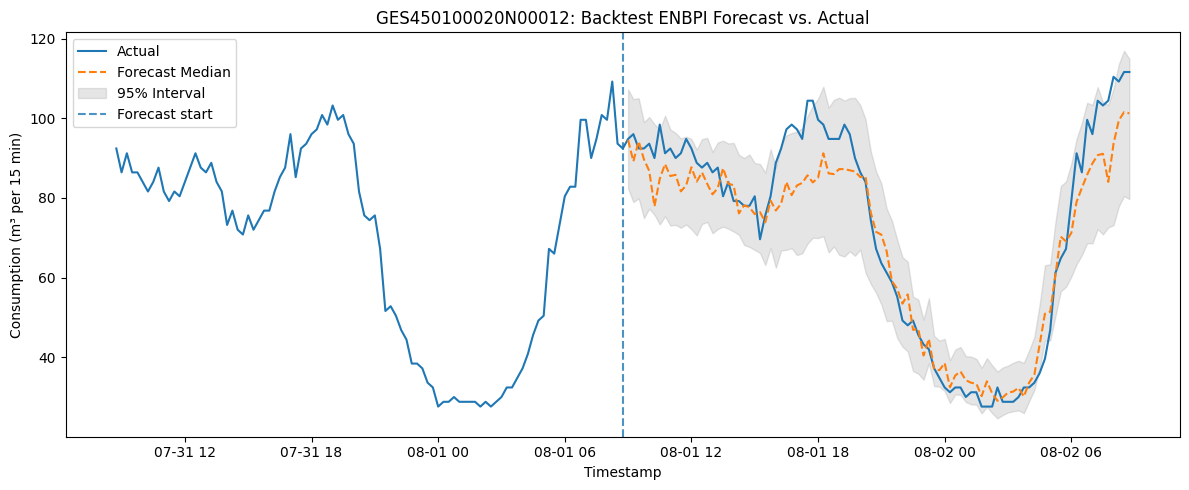

Band coverage: 88.54% (ideal ~95%)


In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import pytz
from datetime import datetime, timedelta
import pandas as pd
from dateutil.parser import ParserError

# Load the ENBPI list (adjust path if from Drive)
#mapie_enbpi_list = joblib.load("/content/drive/MyDrive/Enbpi list/kaggle/working/mapie_enbpi_list.joblib")

def process_batch_to_df(batch):
    dfs = []
    for hist in batch.get("historics", []):
        entry = hist.get("data", {})
        tag = entry.get("tag")
        block = entry.get("data", {})
        ms_list = block.get("ms") or []
        vs_dict = block.get("vs") or {}
        if isinstance(vs_dict, dict) and vs_dict:
            first_key = next(iter(vs_dict))
            values = vs_dict.get(first_key) or []
        else:
            values = []
        if ms_list:
            if isinstance(ms_list[0], str):
                try:
                    timestamps = pd.to_datetime(ms_list)
                except (ValueError, TypeError, ParserError):
                    # Treat as numeric str ms
                    try:
                        ms_list = [int(ms) for ms in ms_list]
                        timestamps = pd.to_datetime(ms_list, unit="ms")
                    except ValueError:
                        print(f"⚠️ Invalid timestamps for {tag}, skipping")
                        continue
            else:
                timestamps = pd.to_datetime(ms_list, unit="ms")
            # Standardize to UTC aware
            if timestamps.tz is None:
                timestamps = timestamps.tz_localize('UTC')
            else:
                timestamps = timestamps.tz_convert('UTC')
        else:
            print(f"⚠️ No timestamps for {tag}, skipping")
            continue
        if len(timestamps) == len(values):
            df_tmp = pd.DataFrame({f"value_{tag}": values}, index=timestamps)
            dfs.append(df_tmp)
        else:
            print(f"⚠️ Length mismatch for {tag}: {len(timestamps)} vs {len(values)}")
    if dfs:
        df_api = pd.concat(dfs, axis=1).sort_index()
    else:
        df_api = pd.DataFrame()
    df_api = df_api.reset_index().rename(columns={'index': 'timestamp'})
    df_api['timestamp'] = pd.to_datetime(df_api['timestamp'], utc=True)  # Redundant safety
    df_api = df_api.sort_values("timestamp").set_index('timestamp')
    return df_api

def calculate_variability_factor(df_prod_sim, station, method='robust_mad', recent_days=None, min_samples=96, clip_min=0.5, clip_max=2.0, power=1.0):
    """
    Calculate station-specific variability factor.
    - method: 'cv' (std/mean), 'robust_mad' (MAD/median), 'residual_cv' (std of residuals / mean).
    - recent_days: If set (e.g., 30), use only last N days of data.
    - power: Exponent to amplify/dampen (e.g., 1.5 to make adjustments stronger).
    """
    def get_station_data(st):
        # Ensure timestamp is the index before slicing by date
        st_data = df_prod_sim[df_prod_sim['station'] == st].set_index('timestamp')['consumption_clean'].sort_index()
        if recent_days is not None:
            end_date = st_data.index.max() # Use index max for slicing
            start_date = end_date - pd.Timedelta(days=recent_days)
            st_data = st_data.loc[start_date:end_date]
        return st_data

    rel_vars = []
    all_stations = df_prod_sim['station'].unique()
    for st in all_stations:
        st_data = get_station_data(st)
        if len(st_data) < min_samples:
            rel_var = 1.0
        else:
            if method == 'robust_mad':
                st_median = st_data.median()
                mad = np.median(np.abs(st_data - st_median))
                rel_var = mad / st_median if st_median > 0 else 1.0
            elif method == 'cv':
                st_mean = st_data.mean()
                st_std = st_data.std()
                rel_var = st_std / st_mean if st_mean > 0 else 1.0
            elif method == 'residual_cv':
                rolling_mean = st_data.rolling(window=4, min_periods=1).mean()  # e.g., 1-hour rolling
                residuals = st_data - rolling_mean
                residuals = residuals.dropna()
                if len(residuals) < 1:
                    rel_var = 1.0
                else:
                    st_mean = st_data.mean()  # Still relative to original mean
                    res_std = residuals.std()
                    rel_var = res_std / st_mean if st_mean > 0 else 1.0
            else:
                raise ValueError("Invalid method")
        rel_vars.append(rel_var)

    median_rel_var = np.median(rel_vars) if rel_vars else 1.0

    # Now for target station
    station_data = get_station_data(station)
    if len(station_data) < min_samples:
        factor = 1.0
    else:
        if method == 'robust_mad':
            station_median = station_data.median()
            mad = np.median(np.abs(station_data - station_median))
            station_rel_var = mad / station_median if station_median > 0 else 1.0
        elif method == 'cv':
            station_mean = station_data.mean()
            station_std = station_data.std()
            station_rel_var = station_std / station_mean if station_mean > 0 else 1.0
        elif method == 'residual_cv':
            rolling_mean = station_data.rolling(window=4, min_periods=1).mean()
            residuals = station_data - rolling_mean
            residuals = residuals.dropna()
            if len(residuals) < 1:
                station_rel_var = 1.0
            else:
                station_mean = station_data.mean()
                res_std = residuals.std()
                station_rel_var = res_std / station_mean if station_mean > 0 else 1.0

        factor = station_rel_var / median_rel_var if median_rel_var > 0 else 1.0
        factor = factor ** power  # Amplify if needed

    factor = max(factor, clip_min)
    factor = min(factor, clip_max)

    # Debug info (adapt to your needs)
    if method == 'cv':
        print(f"Station {station}: std={station_std:.2f}, mean={station_mean:.2f}, rel_var={station_rel_var:.2f}, median_rel_var={median_rel_var:.2f}, factor={factor:.2f}")
    elif method == 'robust_mad':
        print(f"Station {station}: mad={mad:.2f}, median={station_median:.2f}, rel_var={station_rel_var:.2f}, median_rel_var={median_rel_var:.2f}, factor={factor:.2f}")
    elif method == 'residual_cv':
        print(f"Station {station}: res_std={res_std:.2f}, mean={station_mean:.2f}, rel_var={station_rel_var:.2f}, median_rel_var={median_rel_var:.2f}, factor={factor:.2f}")

    return factor

def backtest_enbpi_forecast(station, df_prod, mapie_enbpi_list, station_scalers, features, in_len, horizon, freq, alpha=0.2, backtest_days_ago=5):
    # Simulate data up to 'backtest_days_ago' days before now
    tz = pytz.timezone('Europe/Madrid')
    sim_end = datetime.now(tz) - timedelta(days=backtest_days_ago)
    sim_end = sim_end.astimezone(pytz.utc)
    df_prod_sim = df_prod[df_prod['timestamp'] <= sim_end].copy() # Use .copy() to avoid SettingWithCopyWarning

    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, computed_last_ts = build_last_window(df_prod_sim, station, features, in_len)

    first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
    print(f"Backtest forecast starts at: {first_fc_ts} (simulating run {backtest_days_ago} days ago)")

    # Predict scaled with ENBPI
    y_median_scaled = []
    y_lower_scaled = []
    y_upper_scaled = []
    confidence_level = 1 - alpha
    if len(mapie_enbpi_list) != horizon:
        print(f"Warning: mapie_enbpi_list has {len(mapie_enbpi_list)} estimators, expected {horizon}. Using min length.")
    predict_horizon = min(horizon, len(mapie_enbpi_list))

    for h in range(predict_horizon):
        mapie_h = mapie_enbpi_list[h]
        pred_h, pred_int_h = mapie_h.predict(X_in, confidence_level=confidence_level)
        y_median_scaled.append(pred_h[0])  # Point forecast
        y_lower_scaled.append(pred_int_h[0, 0])  # Lower interval
        y_upper_scaled.append(pred_int_h[0, 1])  # Upper interval

    y_median_scaled = np.array(y_median_scaled)
    y_lower_scaled = np.array(y_lower_scaled)
    y_upper_scaled = np.array(y_upper_scaled)

    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")

    # Inverse scale
    y_lower = scaler.inverse_transform(y_lower_scaled.reshape(-1,1)).flatten()
    y_median = scaler.inverse_transform(y_median_scaled.reshape(-1,1)).flatten()
    y_upper = scaler.inverse_transform(y_upper_scaled.reshape(-1,1)).flatten()

    factor = calculate_variability_factor(df_prod_sim, station, method='cv', recent_days=30, power=1.2)  # Customize: try 'cv' or 'residual_cv', adjust recent_days/power

    # Apply scaling asymmetrically if needed (wider for upside if volatility is skewed)
    interval_width_lower = y_median - y_lower
    interval_width_upper = y_upper - y_median
    y_lower = y_median - interval_width_lower #* factor
    y_upper = y_median + interval_width_upper #* factor  # Could multiply upper by 1.2*factor for asymmetric if upside risk higher

    station_data = df_prod_sim[df_prod_sim["station"] == station]["consumption_clean"]
    station_mean = station_data.mean() if len(station_data) > 1 else 1.0
    epsilon = 1e-5
    trough_factors = (y_median + epsilon) / station_mean
    trough_factors = np.clip(trough_factors, 0.5, 1.5)

    interval_width_lower = y_median - y_lower
    interval_width_upper = y_upper - y_median
    y_lower = y_median - interval_width_lower * trough_factors
    y_upper = y_median + interval_width_upper * trough_factors

    # Ensure lower <= upper after adjustment
    for i in range(len(y_lower)):
        if y_lower[i] > y_upper[i]:
            y_lower[i], y_upper[i] = y_upper[i], y_lower[i]  # Swap if inverted

    # Clip to prevent explosion
    hist_min, hist_max = df_prod_sim[df_prod_sim['station'] == station]['consumption_clean'].min() - 10, df_prod_sim[df_prod_sim['station'] == station]['consumption_clean'].max() + 10
    y_lower = np.clip(y_lower, hist_min, hist_max)
    y_upper = np.clip(y_upper, hist_min, hist_max)


    future_idx = pd.date_range(start=first_fc_ts, periods=predict_horizon, freq=freq, tz='UTC')
    lower = pd.Series(y_lower, index=future_idx, name="Lower")
    median = pd.Series(y_median, index=future_idx, name="Median")
    upper = pd.Series(y_upper, index=future_idx, name="Upper")

    # Actuals for comparison (from full data, including "future" relative to sim)
    df_station = df_prod[df_prod["station"] == station].set_index("timestamp").sort_index()
    if df_station.index.tz is None:
        df_station.index = df_station.index.tz_localize("UTC")
    else:
        df_station.index = df_station.index.tz_convert("UTC")
    past_start = computed_last_ts - pd.Timedelta(days=1)
    past_end = first_fc_ts + pd.Timedelta(hours=24) - pd.Timedelta(minutes=15)
    past_idx = pd.date_range(start=past_start, end=past_end, freq=freq, tz='UTC')
    actual = df_station["consumption_clean"].reindex(past_idx).interpolate(method='time')
    if actual.isna().any():
        actual = actual.ffill().bfill()

    return lower, median, upper, actual, computed_last_ts, first_fc_ts

# Fetch full data (for actuals)
TIMEZONE = 'Europe/Madrid'  # Assuming this is the value; adjust if needed
end_dt = datetime.now(pytz.timezone(TIMEZONE))
start_dt = end_dt - timedelta(days=60)
start_str = start_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
end_str = end_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

batch_full = fetch_historic_batch(station_tags, start_str, end_str)
df_api_full = process_batch_to_df(batch_full)
df_prod = engineer_features_prod(df_api_full, station_scalers, encoder)  # Use df_prod for full

# Force timestamp to datetime UTC (handles if numeric as unix ms or mixed)
def to_timestamp(col):
    if pd.api.types.is_numeric_dtype(col):
        return pd.to_datetime(col, unit='ms', utc=True, errors='coerce')
    return pd.to_datetime(col, utc=True, errors='coerce')

df_prod['timestamp'] = to_timestamp(df_prod['timestamp'])
df_prod = df_prod.dropna(subset=['timestamp'])

# Run backtest
station = "GES450100020N00012"
lower, median, upper, actual, last_obs_ts, fc_start = backtest_enbpi_forecast(station, df_prod, mapie_enbpi_list, station_scalers, features, IN_LENGTH, horizon, FREQ, backtest_days_ago=5)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual, label="Actual")
ax.plot(median, "--", label="Forecast Median")
ax.fill_between(median.index, lower, upper, color='gray', alpha=0.2, label="95% Interval")
ax.axvline(last_obs_ts, linestyle="--", alpha=0.8, label="Forecast start")
ax.set_title(f"{station}: Backtest ENBPI Forecast vs. Actual")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption (m³ per 15 min)")
ax.legend()
plt.tight_layout()
plt.show()

# Coverage metric ( % actuals in band for forecast period)
fc_actual = actual[fc_start:]
in_band = (fc_actual >= lower) & (fc_actual <= upper)
coverage = np.mean(in_band) * 100
print(f"Band coverage: {coverage:.2f}% (ideal ~95%)")

## ENBPI Inference

/tmp/ipython-input-3325631816.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(clean_and_flag).reset_index(drop=True)
/tmp/ipython-input-3325631816.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("station", group_keys=False).apply(scale_group_prod).reset_index(drop=True)
/tmp/ipython-input-3325631816.py:112: DeprecationWarning: Data

Forecast starts at: 2025-08-06 07:30:00+00:00


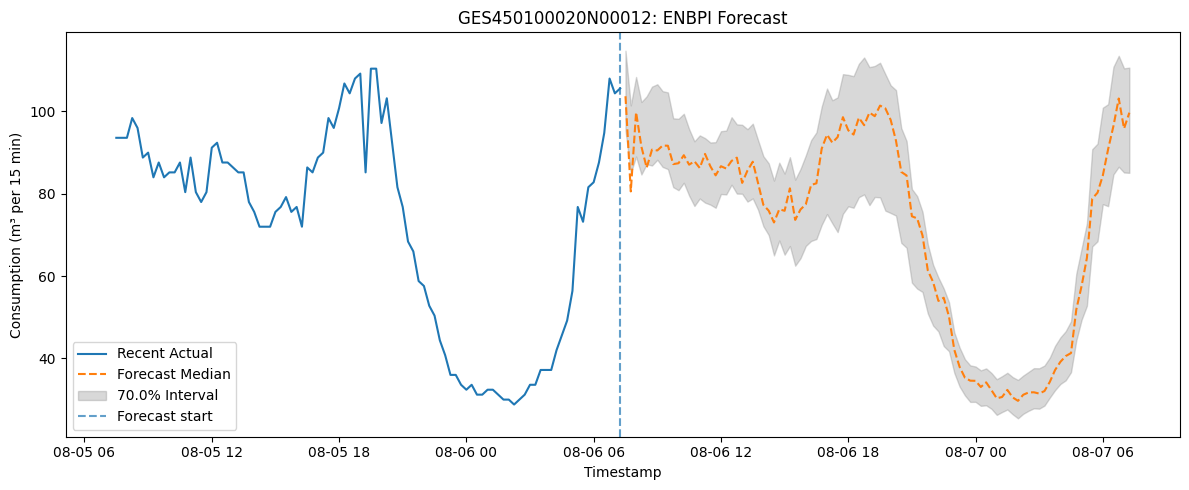

In [ ]:
# New function for inference (forward forecast)
def forecast_enbpi(station, station_tags, station_scalers, encoder, features, in_len, horizon, freq, alpha=0.2):
    # Fetch recent data for input window (last 60 days to be safe, but use only last in_len)
    end_dt = datetime.now(pytz.timezone(TIMEZONE))
    start_dt = end_dt - timedelta(days=60)
    start_str = start_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
    end_str = end_dt.astimezone(pytz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

    batch_recent = fetch_historic_batch(station_tags, start_str, end_str)
    df_api_recent = process_batch_to_df(batch_recent)
    df_recent = engineer_features_prod(df_api_recent, station_scalers, encoder)
    # Force timestamp to UTC datetime
    def to_timestamp(col):
        if pd.api.types.is_numeric_dtype(col):
            return pd.to_datetime(col, unit='ms', utc=True, errors='coerce')
        return pd.to_datetime(col, utc=True, errors='coerce')

    df_recent['timestamp'] = to_timestamp(df_recent['timestamp'])
    df_recent = df_recent.dropna(subset=['timestamp'])

    # Build last input window
    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, last_ts = build_last_window(df_recent, station, features, in_len)

    first_fc_ts = last_ts + pd.Timedelta(minutes=15)
    print(f"Forecast starts at: {first_fc_ts}")

    # Predict scaled with ENBPI
    y_median_scaled = []
    y_lower_scaled = []
    y_upper_scaled = []
    confidence_level = 1 - alpha
    for h, mapie_h in enumerate(mapie_enbpi_list):
        pred_h, pred_int_h = mapie_h.predict(X_in, confidence_level=confidence_level)
        y_median_scaled.append(pred_h[0])
        y_lower_scaled.append(pred_int_h[0, 0])
        y_upper_scaled.append(pred_int_h[0, 1])

    y_median_scaled = np.array(y_median_scaled)
    y_lower_scaled = np.array(y_lower_scaled)
    y_upper_scaled = np.array(y_upper_scaled)

    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")

    # Inverse scale
    y_lower = scaler.inverse_transform(y_lower_scaled.reshape(-1,1)).flatten()
    y_median = scaler.inverse_transform(y_median_scaled.reshape(-1,1)).flatten()
    y_upper = scaler.inverse_transform(y_upper_scaled.reshape(-1,1)).flatten()

    station_data = df_prod[df_prod["station"] == station]["consumption_clean"]
    station_mean = station_data.mean() if len(station_data) > 1 else 1.0
    epsilon = 1e-5
    trough_factors = (y_median + epsilon) / station_mean
    trough_factors = np.clip(trough_factors, 0.5, 1.5)

    interval_width_lower = y_median - y_lower
    interval_width_upper = y_upper - y_median
    y_lower = y_median - interval_width_lower * trough_factors # to dampen add trough facors **5
    y_upper = y_median + interval_width_upper * trough_factors

    # Ensure lower <= upper
    for i in range(len(y_lower)):
        if y_lower[i] > y_upper[i]:
            y_lower[i], y_upper[i] = y_upper[i], y_lower[i]

    # Clip based on historical range
    hist_min, hist_max = df_recent[df_recent['station'] == station]['consumption_clean'].min() - 10, df_recent[df_recent['station'] == station]['consumption_clean'].max() + 10
    y_lower = np.clip(y_lower, hist_min, hist_max)
    y_upper = np.clip(y_upper, hist_min, hist_max)

    # Create forecast series
    future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=freq, tz='UTC')
    lower = pd.Series(y_lower, index=future_idx, name="Lower")
    median = pd.Series(y_median, index=future_idx, name="Median")
    upper = pd.Series(y_upper, index=future_idx, name="Upper")

    # Plot forecast
    fig, ax = plt.subplots(figsize=(12, 5))
    # Plot recent actuals for context
    recent_actual = df_recent[df_recent["station"] == station].set_index("timestamp")["consumption_clean"].tail(96)
    ax.plot(recent_actual, label="Recent Actual")
    ax.plot(median, "--", label="Forecast Median")
    ax.fill_between(median.index, lower, upper, color='gray', alpha=0.3, label=f"{(1-alpha)*100}% Interval")
    ax.axvline(last_ts, linestyle="--", alpha=0.7, label="Forecast start")
    ax.set_title(f"{station}: ENBPI Forecast")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Consumption (m³ per 15 min)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return lower, median, upper

# Example usage
station = "GES450100020N00012"
# Assuming station_tags is a list including this station
station_tags = [station]  # Or your full list
lower, median, upper = forecast_enbpi(station, station_tags, station_scalers, encoder, features, IN_LENGTH, horizon, FREQ, alpha=0.3, use_factor=False)

## Anomaly Flagging

Backtest forecast starts at: 2025-07-26 09:15:00+00:00 (simulating run 10 days ago)
Simulated leak: Multiplied consumption by 3.0 for 8 points starting at 2025-07-26 14:15:00+00:00 (random offset: 20)
Station GES450100020N00012: mad=16.80, median=78.00, rel_var=0.22, median_rel_var=0.24, factor=0.87
Anomaly flags:
2025-07-26 10:00:00+00:00    True
2025-07-26 10:15:00+00:00    True
2025-07-26 10:30:00+00:00    True
2025-07-26 12:45:00+00:00    True
2025-07-26 13:15:00+00:00    True
2025-07-26 14:15:00+00:00    True
2025-07-26 14:30:00+00:00    True
2025-07-26 14:45:00+00:00    True
2025-07-26 15:00:00+00:00    True
2025-07-26 15:15:00+00:00    True
2025-07-26 15:30:00+00:00    True
2025-07-26 15:45:00+00:00    True
2025-07-26 16:00:00+00:00    True
2025-07-26 17:00:00+00:00    True
2025-07-26 17:15:00+00:00    True
2025-07-26 17:30:00+00:00    True
2025-07-26 17:45:00+00:00    True
2025-07-26 18:00:00+00:00    True
2025-07-26 18:15:00+00:00    True
2025-07-26 18:30:00+00:00    True
2025

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

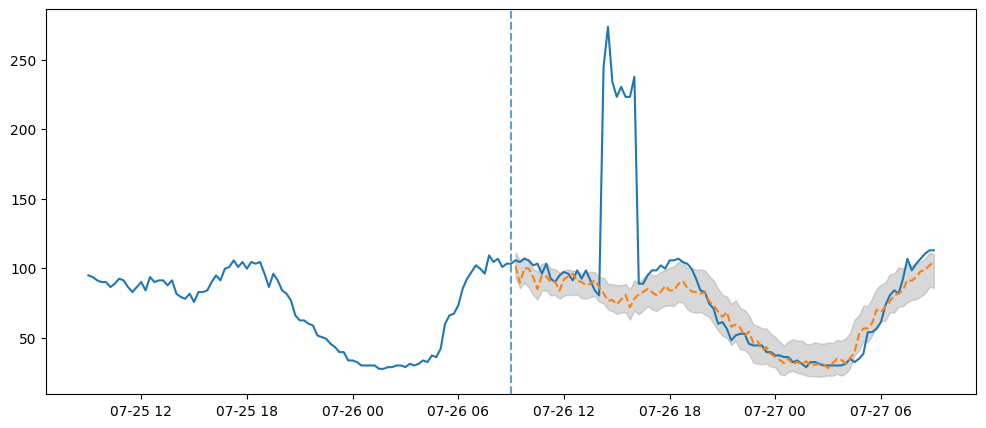

In [ ]:
import numpy as np
def backtest_enbpi_forecast(station, df_prod, mapie_enbpi_list, station_scalers, features, in_len, horizon, freq, alpha=0.2, backtest_days_ago=5, simulate_leak=False, leak_magnitude=2.0, leak_duration=4):
    # Simulate data up to 'backtest_days_ago' days before now
    tz = pytz.timezone('Europe/Madrid')
    sim_end = datetime.now(tz) - timedelta(days=backtest_days_ago)
    sim_end = sim_end.astimezone(pytz.utc)
    df_prod_sim = df_prod[df_prod['timestamp'] <= sim_end].copy()

    def build_last_window(df, station_tag, feats, in_len):
        sub = df[df["station"] == station_tag].sort_values("timestamp").reset_index(drop=True)
        if len(sub) < in_len:
            raise ValueError(f"{station_tag}: only {len(sub)} rows (<{in_len})")
        block = sub.iloc[-in_len:]
        Xw = block[feats + ["station_encoded"]].to_numpy().reshape(1, -1)
        return Xw, block["timestamp"].iloc[-1]

    X_in, computed_last_ts = build_last_window(df_prod_sim, station, features, in_len)

    first_fc_ts = computed_last_ts + pd.Timedelta(minutes=15)
    print(f"Backtest forecast starts at: {first_fc_ts} (simulating run {backtest_days_ago} days ago)")

    # Simulate leak
    df_prod_modified = df_prod.copy()
    if simulate_leak:
        max_offset = max(0,horizon - leak_duration)
        random_offset = np.random.randint(0, max_offset + 1)
        leak_start = first_fc_ts + pd.Timedelta(minutes=15 * random_offset)
        leak_end = leak_start + pd.Timedelta(minutes=15 * (leak_duration - 1))
        mask = (df_prod_modified["station"] == station) & (df_prod_modified["timestamp"] >= leak_start) & (df_prod_modified['timestamp'] <= leak_end)

        if mask.sum() > 0:
            df_prod_modified.loc[mask, 'consumption_clean'] *= leak_magnitude
            print(f"Simulated leak: Multiplied consumption by {leak_magnitude} for {leak_duration} points starting at {leak_start} (random offset: {random_offset})")
        else:
            print("Warning: No data points in the leak period; simulation skipped.")

    # Predict scaled with ENBPI
    y_median_scaled = []
    y_lower_scaled = []
    y_upper_scaled = []
    confidence_level = 1 - alpha
    for h, mapie_h in enumerate(mapie_enbpi_list):
        pred_h, pred_int_h = mapie_h.predict(X_in, confidence_level=confidence_level)
        y_median_scaled.append(pred_h[0])  # Point forecast
        y_lower_scaled.append(pred_int_h[0, 0])  # Lower interval
        y_upper_scaled.append(pred_int_h[0, 1])  # Upper interval

    y_median_scaled = np.array(y_median_scaled)
    y_lower_scaled = np.array(y_lower_scaled)
    y_upper_scaled = np.array(y_upper_scaled)

    scaler = station_scalers.get(station)
    if scaler is None:
        raise ValueError(f"No scaler for station {station}")

    # Inverse scale
    y_lower = scaler.inverse_transform(y_lower_scaled.reshape(-1,1)).flatten()
    y_median = scaler.inverse_transform(y_median_scaled.reshape(-1,1)).flatten()
    y_upper = scaler.inverse_transform(y_upper_scaled.reshape(-1,1)).flatten()

    factor = calculate_variability_factor(df_prod_sim, station, method='robust_mad', recent_days=30, power=1.2)

    # Apply scaling
    interval_width_lower = y_median - y_lower
    interval_width_upper = y_upper - y_median
    y_lower = y_median - interval_width_lower #* factor
    y_upper = y_median + interval_width_upper #* factor

    # Ensure lower <= upper
    for i in range(len(y_lower)):
        if y_lower[i] > y_upper[i]:
            y_lower[i], y_upper[i] = y_upper[i], y_lower[i]

    # Clip
    hist_min, hist_max = df_prod_sim[df_prod_sim['station'] == station]['consumption_clean'].min() - 10, df_prod_sim[df_prod_sim['station'] == station]['consumption_clean'].max() + 10
    y_lower = np.clip(y_lower, hist_min, hist_max)
    y_upper = np.clip(y_upper, hist_min, hist_max)

    future_idx = pd.date_range(start=first_fc_ts, periods=horizon, freq=freq, tz='UTC')
    lower = pd.Series(y_lower, index=future_idx, name="Lower")
    median = pd.Series(y_median, index=future_idx, name="Median")
    upper = pd.Series(y_upper, index=future_idx, name="Upper")

    # Actuals (use modified df for simulation)
    df_station = df_prod_modified[df_prod_modified["station"] == station].set_index("timestamp").sort_index()
    if df_station.index.tz is None:
        df_station.index = df_station.index.tz_localize("UTC")
    else:
        df_station.index = df_station.index.tz_convert("UTC")
    past_start = computed_last_ts - pd.Timedelta(days=1)
    past_end = first_fc_ts + pd.Timedelta(hours=24) - pd.Timedelta(minutes=15)
    past_idx = pd.date_range(start=past_start, end=past_end, freq=freq, tz='UTC')
    actual = df_station["consumption_clean"].reindex(past_idx).interpolate(method='time')
    if actual.isna().any():
        actual = actual.ffill().bfill()

    # Flag anomalies in forecast period
    fc_actual = actual[first_fc_ts:]
    flags = pd.Series(index=fc_actual.index, dtype=bool, name="Anomaly Flag")
    station_data = df_prod_sim[df_prod_sim['station'] == station]['consumption_clean']
    station_std = station_data.std() if len(station_data) > 1 else 1.0

    for ts in fc_actual.index:
        val = fc_actual[ts]
        med = median.get(ts, np.nan)
        low = lower.get(ts, np.nan)
        up = upper.get(ts, np.nan)
        # Flag if outside interval OR exceeds variability threshold
        is_anomaly = (val < low or val > up) or (val > med + (3 * factor * station_std))
        flags[ts] = is_anomaly

    print(f"Anomaly flags:\n{flags[flags == True]}")  # Print flagged points

    return lower, median, upper, actual, computed_last_ts, first_fc_ts, flags

station = "GES450100020N00012"
station_tags = [station]
# Fetch and process data as before...
lower, median, upper, actual, last_obs_ts, fc_start, flags = backtest_enbpi_forecast(
    station, df_prod, mapie_enbpi_list, station_scalers, features, IN_LENGTH, horizon, FREQ,
    backtest_days_ago=10, simulate_leak=True, leak_magnitude=3.0, leak_duration=8
)

# Plot with flags
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual, label="Actual (with simulated leak)")
ax.plot(median, "--", label="Forecast Median")
ax.fill_between(median.index, lower, upper, color='gray', alpha=0.3, label="95% Interval")
ax.axvline(last_obs_ts, linestyle="--", alpha=0.7, label="Forecast start")
# Highlight anomalies
anomaly_points = actual[flags == True]
ax.scatter(anomaly_points.index, anomaly_points, color='red', label="Flagged Anomaly/Leak")
ax.set_title(f"{station}: Backtest with Simulated Leak")
ax.legend()
plt.show()

# Coverage (adjusted for anomalies)
fc_actual = actual[fc_start:]
in_band = (fc_actual >= lower) & (fc_actual <= upper)
coverage = np.mean(in_band) * 100
print(f"Band coverage: {coverage:.2f}% (ideal ~95%; lower if leak not captured)")